# Batched personalized PageRank — the agent-retrieval workhorse

HippoRAG-style retrieval, aider's repo-map ranking, and Graphiti-style
memory all reduce to the same primitive: *"given these seed entities, rank
everything else"* — personalized PageRank, issued in bursts of queries per
agent step.

`mg.ppr_topk` runs a whole batch in one call: queries are packed into
8-lane tiles that share each pass over the graph, converge independently,
and return only the `(B, k)` top scores — never a dense `B x V` result.

The graph here is a synthetic knowledge-graph shape (power-law degrees,
weighted, **V=50k, E=1.2M** — above the planner's 1M-edge GPU
threshold) so the whole notebook runs in seconds.

In [1]:
import time
import numpy as np
import metal_graph as mg

rng = np.random.default_rng(7)
V, E = 50_000, 1_200_000
# power-law out-degrees that sum to ~E
raw = rng.zipf(1.8, V).astype(np.float64)
deg = np.maximum(1, np.round(raw * (E / raw.sum()))).astype(np.int64)
src = np.repeat(np.arange(V, dtype=np.uint32), deg)[:E]
if src.size < E:
    src = np.concatenate([src, rng.integers(0, V, E - src.size,
                                            dtype=np.uint32)])
dst = (rng.zipf(1.6, E) - 1) % V
dst = rng.permutation(V).astype(np.uint32)[dst]
w = rng.uniform(0.1, 2.0, E).astype(np.float32)

t0 = time.perf_counter()
G = mg.Graph.from_edges(src, dst.astype(np.uint32), weights=w,
                        directed=True, num_vertices=V)
print(f"built V={G.num_vertices:,} E={G.num_edges:,} in "
      f"{(time.perf_counter()-t0)*1e3:.1f} ms (the build IS the upload)")

built V=50,000 E=1,200,000 in 61.4 ms (the build IS the upload)


## One agent step: 16 queries, one call

Each query personalizes on 1–4 seed entities and wants the top 64 results.

In [2]:
B, k = 16, 64
counts = rng.integers(1, 5, B)
offsets = np.zeros(B + 1, np.uint64)
offsets[1:] = np.cumsum(counts)
seeds = rng.integers(0, V, int(offsets[-1])).astype(np.uint32)
weights = rng.uniform(0.5, 2.0, seeds.size).astype(np.float32)

kw = dict(k=k, alpha=0.85, tol=1e-6, max_iter=50)
ids, scores = mg.ppr_topk(G, seeds, weights, offsets, **kw)  # warm-up

runs = []
for _ in range(15):
    t0 = time.perf_counter()
    ids, scores = mg.ppr_topk(G, seeds, weights, offsets, **kw)
    runs.append((time.perf_counter() - t0) * 1e3)
batch_ms = float(np.median(runs))
info = mg.last_run_info()

print(f"batch of {B} queries: {batch_ms:.2f} ms  "
      f"({batch_ms/B:.3f} ms/query amortized)  "
      f"path={info['path']} iterations={info['iterations']}")
print("query 0 seeds:", seeds[:int(counts[0])].tolist())
print("query 0 top-5:", list(zip(np.asarray(ids)[0, :5].tolist(),
                                 np.round(np.asarray(scores)[0, :5], 5))))

batch of 16 queries: 4.84 ms  (0.303 ms/query amortized)  path=gpu iterations=10
query 0 seeds: [15488, 2889, 2688]
query 0 top-5: [(3077, np.float32(0.7375)), (2688, np.float32(0.05292)), (15488, np.float32(0.04993)), (2889, np.float32(0.04715)), (29403, np.float32(0.04244))]


## Batching is free accuracy-wise — and much faster

Batched results are **bit-identical** to running the same queries one at a
time (the test suite asserts this exactly); the batch simply shares the
memory traffic.

In [3]:
t0 = time.perf_counter()
seq_rows = []
for q in range(B):
    lo, hi = int(offsets[q]), int(offsets[q + 1])
    off1 = np.array([0, hi - lo], np.uint64)
    i1, s1 = mg.ppr_topk(G, seeds[lo:hi], weights[lo:hi], off1, **kw)
    seq_rows.append((np.asarray(i1)[0], np.asarray(s1)[0]))
seq_ms = (time.perf_counter() - t0) * 1e3

bit_identical = all(
    np.array_equal(np.asarray(ids)[q], seq_rows[q][0])
    and np.array_equal(np.asarray(scores)[q], seq_rows[q][1])
    for q in range(B))
print(f"16 sequential calls: {seq_ms:.1f} ms  vs  batch {batch_ms:.2f} ms  "
      f"-> {seq_ms/batch_ms:.1f}x from batching alone")
print("batched == sequential, bit-identical:", bit_identical)

16 sequential calls: 30.1 ms  vs  batch 4.84 ms  -> 6.2x from batching alone
batched == sequential, bit-identical: True


## Against a strong CPU baseline

igraph's `personalized_pagerank` (PRPACK, C) is the fastest maintained CPU
comparator. It solves exactly rather than iterating, so this is context,
not an identical-work race — see the repo's benchmark report for the full
methodology.

In [4]:
try:
    import igraph as ig
    gi = ig.Graph(n=V, edges=list(zip(src.tolist(), dst.tolist())),
                  directed=True)
    gi.es["weight"] = w.tolist()
    t0 = time.perf_counter()
    for q in range(B):
        lo, hi = int(offsets[q]), int(offsets[q + 1])
        reset = np.zeros(V)
        reset[seeds[lo:hi]] = weights[lo:hi]
        sc = np.asarray(gi.personalized_pagerank(
            damping=0.85, reset=reset, weights="weight"))
        top = np.argpartition(-sc, k - 1)[:k]
    ig_ms = (time.perf_counter() - t0) * 1e3
    print(f"igraph 16-query loop: {ig_ms:.0f} ms "
          f"({ig_ms/B:.1f} ms/query)  ->  metal-graph batch is "
          f"{ig_ms/batch_ms:.0f}x faster end-to-end")
except ImportError:
    ig_ms = None
    print("igraph not installed - skipping the baseline comparison")

igraph 16-query loop: 329 ms (20.6 ms/query)  ->  metal-graph batch is 68x faster end-to-end


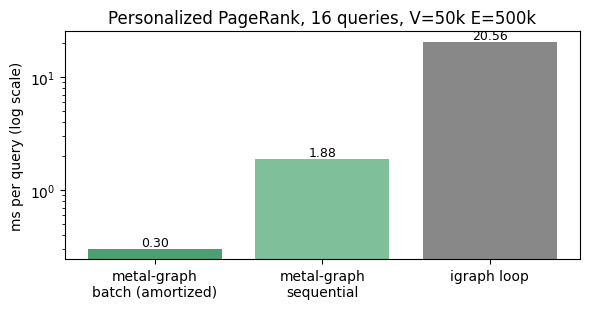

In [5]:
import matplotlib.pyplot as plt

labels = ["metal-graph\nbatch (amortized)", "metal-graph\nsequential"]
vals = [batch_ms / B, seq_ms / B]
if ig_ms is not None:
    labels.append("igraph loop")
    vals.append(ig_ms / B)
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.bar(labels, vals, color=["#4C9F70", "#7fbf9a", "#888888"][:len(vals)])
ax.set_ylabel("ms per query (log scale)")
ax.set_yscale("log")
ax.set_title(f"Personalized PageRank, {B} queries, V=50k E=500k")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

**Takeaways** — one call ranks entities for a whole burst of agent
queries at sub-millisecond amortized cost; batching is bit-exact; and the
gap versus a strong CPU baseline is one-to-two orders of magnitude at this
scale (see `bench/` for the provenance-stamped numbers on bigger graphs).